In [4]:
!pip install patsy bambi


In [5]:
import os
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.regression.mixed_linear_model import MixedLM
from statsmodels.stats.multitest import multipletests
from patsy import dmatrices
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# READ DATA

In [3]:
# --------------------------------------------------
# 0. Paths and output dir
# --------------------------------------------------
EOP_PATH        = "eop_raw_values.csv"
AMR_GENES_PATH  = "amrfinderplus_all.tsv"
DEFENSE_PATH    = "TableS3-defenseSystems.xlsx"
AMR_PHENO       = "amrresults.csv"
PHAGE_GENES_PATH= "Phage_tail_clusters_WClusterID.tsv"
# PHAGE_GENES_PATH= "Phage_gene_matrix.csv"

# os.makedirs(OUTDIR, exist_ok=True)

# --------------------------------------------------
# 1. Helper functions
# --------------------------------------------------
def canon_host(name: str) -> str:
    """
    Normalize host names across tables.
    Examples:
      'A xylosoxidans jini'  -> 'A xylosoxidans jini'
      'A. xylosoxidans jini' -> 'A xylosoxidans jini'
    """
    if pd.isna(name):
        return np.nan
    s = str(name).strip()
    # remove "A." vs "A "
    s = s.replace("A. ", "A ")
    s = s.replace("A.", "A ")
    s = s.replace(".", "")
    # collapse whitespace
    s = " ".join(s.split())
    return s

def host_id_from_canon(canon: str) -> str:
    if pd.isna(canon):
        return np.nan
    return canon.lower().replace(" ", "_")

def host_species_from_canon(canon: str) -> str:
    """Assume 'A xylosoxidans jini' -> species 'xylosoxidans'."""
    if pd.isna(canon):
        return np.nan
    parts = canon.split()
    return parts[1] if len(parts) >= 2 else np.nan

def canon_phage(name: str) -> str:
    if pd.isna(name):
        return np.nan
    return str(name).strip().lower()

def logit(x):
    x = np.clip(x, 1e-9, 1 - 1e-9)
    return np.log(x / (1 - x))

def scale_safely(x: pd.Series) -> pd.Series:
    if not np.issubdtype(x.dtype, np.number):
        return x
    m = np.nanmean(x)
    s = np.nanstd(x, ddof=1)
    if s == 0 or np.isnan(s):
        return pd.Series(0.0, index=x.index)
    return (x - m) / s


In [4]:

# --------------------------------------------------
# 2. Load and reshape EOP table (phage × host -> long)
# --------------------------------------------------
eop_wide = pd.read_csv(EOP_PATH)

# EOP column = phage name
eop_long = eop_wide.melt(
    id_vars=["EOP"],
    var_name="host_raw",
    value_name="EOP_value"
)

# rename phage column and normalise
eop_long = eop_long.rename(columns={"EOP": "phage_raw"})
eop_long["phage_id"] = eop_long["phage_raw"].apply(canon_phage)

# host naming and species
eop_long["host_canon"]   = eop_long["host_raw"].apply(canon_host)
eop_long['bacteria']      = eop_long['host_raw']
eop_long["host_id"]      = eop_long["host_canon"].apply(host_id_from_canon)
eop_long["host_species"] = eop_long["host_canon"].apply(host_species_from_canon)

# EOP numeric
eop_long["EOP_value"] = pd.to_numeric(eop_long["EOP_value"], errors="coerce")
eop_long

,phage_raw,host_raw,EOP_value,phage_id,host_canon,bacteria,host_id,host_species
0,Coliflower,A xylosoxidans jini,1.780000e+01,coliflower,A xylosoxidans jini,A xylosoxidans jini,a_xylosoxidans_jini,xylosoxidans
1,Infector,A xylosoxidans jini,2.500000e-01,infector,A xylosoxidans jini,A xylosoxidans jini,a_xylosoxidans_jini,xylosoxidans
2,Yaccob,A xylosoxidans jini,3.750000e-04,yaccob,A xylosoxidans jini,A xylosoxidans jini,a_xylosoxidans_jini,xylosoxidans
3,Rage,A xylosoxidans jini,7.690000e-08,rage,A xylosoxidans jini,A xylosoxidans jini,a_xylosoxidans_jini,xylosoxidans
4,Patchman,A xylosoxidans jini,6.150000e-07,patchman,A xylosoxidans jini,A xylosoxidans jini,a_xylosoxidans_jini,xylosoxidans
...,...,...,...,...,...,...,...,...
100,ewik,A insolitus cram,2.500000e-06,ewik,A insolitus cram,A insolitus cram,a_insolitus_cram,insolitus
101,maay,A insolitus cram,2.000000e-02,maay,A insolitus cram,A insolitus cram,a_insolitus_cram,insolitus
102,tuull,A insolitus cram,5.830000e-05,tuull,A insolitus cram,A insolitus cram,a_insolitus_cram,insolitus
103,nyashin,A insolitus cram,2.670000e-03,nyashin,A insolitus cram,A insolitus cram,a_insolitus_cram,insolitus


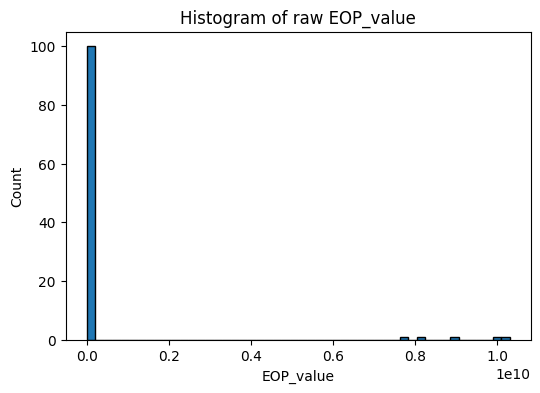

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(eop_long["EOP_value"], bins=50, edgecolor="black")
plt.xlabel("EOP_value")
plt.ylabel("Count")
plt.title("Histogram of raw EOP_value")
plt.show()

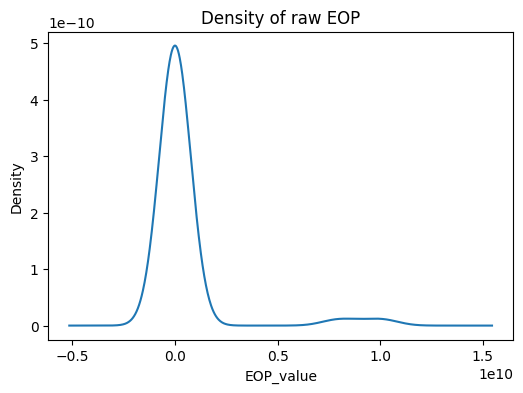

In [6]:
eop_long["EOP_value"].plot(kind="density", figsize=(6,4), title="Density of raw EOP")
plt.xlabel("EOP_value")
plt.show()

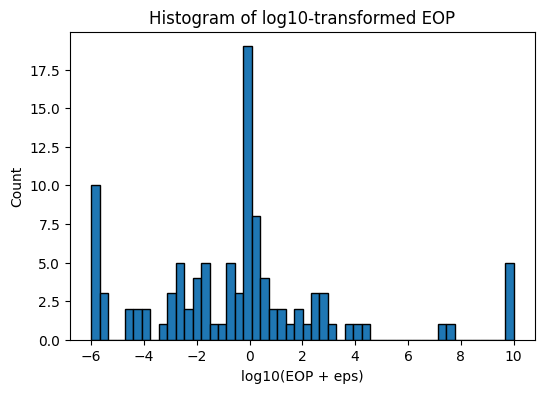

In [7]:
import numpy as np

eps = 1e-6
eop_long["log_EOP"] = np.log10(eop_long["EOP_value"] + eps)
plt.figure(figsize=(6,4))
plt.hist(eop_long["log_EOP"], bins=50, edgecolor="black")
plt.xlabel("log10(EOP + eps)")
plt.ylabel("Count")
plt.title("Histogram of log10-transformed EOP")
plt.show()

In [8]:
# --------------------------------------------------
# 3. Defence systems per host (TableS3-defenseSystems.xlsx)
# --------------------------------------------------
def_df = pd.read_excel(DEFENSE_PATH)

# normalise host names
def_df["host_canon"] = def_df["bacteria"].apply(canon_host)
def_df["host_id"]    = def_df["host_canon"].apply(host_id_from_canon)

# focus on defence systems
def_df["genes_count"] = pd.to_numeric(def_df["genes_count"], errors="coerce").fillna(0)

def_df_melted = (
    def_df
    .groupby(["bacteria", "subtype"])["genes_count"]
    .sum()
    .reset_index(name="count")
)
def_df_melted


,bacteria,subtype,count
0,A. insolitus aura,CBASS_III,5
1,A. insolitus aura,Kiwa,2
2,A. insolitus aura,RM_Type_II,2
3,A. insolitus aura,Shedu,1
4,A. insolitus cram,CBASS_III,5
5,A. insolitus cram,Kiwa,3
6,A. insolitus neet,CBASS_II,4
7,A. insolitus neet,CBASS_III,5
8,A. insolitus neet,Kiwa,2
9,A. insolitus neet,Shedu,1


In [13]:
# --------------------------------------------------
# 4. AMR gene counts per host (amrfinderplus_all.tsv)
# --------------------------------------------------
amr = pd.read_csv(AMR_GENES_PATH, sep="\t")

amr["bacteria"] = amr["sample"]

# count by Class (BETA-LACTAM, AMINOGLYCOSIDE, TETRACYCLINE, etc.)
amr_class_counts = (
    amr.groupby(["bacteria", "Subclass"])["Protein id"]
    .nunique()
    .unstack("Subclass", fill_value=0)
)

amr_class_counts["AMR_counts"] = amr_class_counts.sum(axis=1)
amr_class_counts = amr_class_counts.reset_index()
#amr_class_counts
amr_class_counts_melt = amr_class_counts.melt(
    id_vars=["bacteria"],
    var_name="AMR_class",
    value_name="count"
)
amr_class_counts_melt
amr_class_counts_melt = amr_class_counts_melt[~amr_class_counts_melt['AMR_class'].str.contains('AMR_counts', na=False)]
amr_class_counts_melt

,bacteria,AMR_class,count
0,A. insolitus aura,AMINOGLYCOSIDE,2
1,A. insolitus cram,AMINOGLYCOSIDE,2
2,A. insolitus neet,AMINOGLYCOSIDE,1
3,A. insolitus vya,AMINOGLYCOSIDE,0
4,A. xylosoxidans ayb,AMINOGLYCOSIDE,0
5,A. xylosoxidans jini,AMINOGLYCOSIDE,1
6,A. xylosoxidans suz,AMINOGLYCOSIDE,1
7,A. insolitus aura,BETA-LACTAM,3
8,A. insolitus cram,BETA-LACTAM,2
9,A. insolitus neet,BETA-LACTAM,1


In [14]:
# --------------------------------------------------
# 4. AMR phenptype per host (amrresults.csv)
# --------------------------------------------------
amr_pheno = pd.read_csv(AMR_PHENO)
map_vals = {"S": 1, "I": 0, "R": -1}

# apply mapping to all host columns
host_cols = amr_pheno.columns[2:]   # everything after the first two cols
amr_pheno[host_cols] = amr_pheno[host_cols].replace(map_vals)
amr_pheno.drop(columns=["Antibiotic subclass"], inplace=True)
amr_phenoT=amr_pheno.T
amr_phenoT.columns=amr_phenoT.iloc[0]
amr_phenoT=amr_phenoT.drop(amr_phenoT.index[0])
amr_phenoT=amr_phenoT.reset_index()
amr_phenoT=amr_phenoT.rename(columns={"index":"bacteria"})
amr_phenoT

amr_phenoT_melt = amr_phenoT.melt(
    id_vars=["bacteria"],
    var_name="AMR_class",
    value_name="count"
)
# drop NA values in "count"
amr_phenoT_melt = amr_phenoT_melt.dropna(subset=["count"])

amr_phenoT_melt

/tmp/ipython-input-3434045863.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  amr_pheno[host_cols] = amr_pheno[host_cols].replace(map_vals)


,bacteria,AMR_class,count
0,A. xylosoxidans jini,Piperacillin/tazobactam,1
1,A. xylosoxidans ayb,Piperacillin/tazobactam,1
2,A. xylosoxidans suz,Piperacillin/tazobactam,1
3,A. insolitus neet,Piperacillin/tazobactam,-1
4,A. insolitus aura,Piperacillin/tazobactam,-1
...,...,...,...
233,A. xylosoxidans suz,Tetracycline,-1
234,A. insolitus neet,Tetracycline,-1
235,A. insolitus aura,Tetracycline,-1
236,A. insolitus cram,Tetracycline,-1


In [22]:
# --------------------------------------------------
# 5. Phage tail/structural gene features (Phage_gene_matrix.csv)
# --------------------------------------------------
pg = pd.read_csv(PHAGE_GENES_PATH, sep="\t")

phage_cluster_counts = (
    pg
    .groupby(["queryID", "cluster"])["qgeneID"]
    .nunique()  # number of distinct genes per phage per cluster
    .reset_index(name="gene_count")
)
phage_cluster_counts

,queryID,cluster,gene_count
0,coliflower,cluster_1,2
1,coliflower,cluster_2,1
2,ewik,cluster_1,1
3,ewik,cluster_2,1
4,gadget,cluster_1,1
5,infector,cluster_1,1
6,infector,cluster_2,1
7,infector,cluster_3,1
8,kuwaak,cluster_1,1
9,kuwaak,cluster_4,1


# MERGE TABLES

In [23]:
def normalize(s):
    return (s
              .replace(".", "")   # remove periods
              .strip())

In [26]:
# --------------------------------------------------
# 6. Build final analysis table: merge everything
# --------------------------------------------------
data=pd.DataFrame()

# Ensure 'bacteria' and 'phage_id' columns are standardized as strings for merging
eop_long["bacteria"] = eop_long["bacteria"].astype(str)
eop_long["bacteria"] = eop_long['bacteria'].apply(normalize)

def_df_melted["bacteria"] = def_df_melted["bacteria"].astype(str)
def_df_melted["bacteria"] = def_df_melted['bacteria'].apply(normalize)

amr_class_counts_melt["bacteria"] = amr_class_counts_melt["bacteria"].astype(str)
amr_class_counts_melt["bacteria"] = amr_class_counts_melt['bacteria'].apply(normalize)

amr_phenoT_melt["bacteria"] = amr_phenoT_melt["bacteria"].astype(str)
amr_phenoT_melt["bacteria"] = amr_phenoT_melt['bacteria'].apply(normalize)

tail_counts["phage_id"] = tail_counts["phage_id"].astype(str)
eop_long["phage_id"] = eop_long["phage_id"].astype(str)

# 1. Merge EOP data with defense system data (long format for 'subtype')
# This will result in multiple rows per phage-host pair if a host has multiple defense subtypes,
# which is suitable for models treating 'subtype' as a categorical predictor.
# The 'count' column from `def_df_melted` becomes `defense_genes_counts`.
data = eop_long.merge(
    def_df_melted,
    how='left',
    left_on='bacteria',
    right_on='bacteria'
)
data = data.rename(columns={'count': 'defense_genes_counts'})

# 2. Merge AMR gene counts (amr_class_counts - already wide format)
# This adds columns like 'AMINOGLYCOSIDE', 'BETA-LACTAM', 'AMR_counts' directly.
data = data.merge(
    amr_class_counts_melt,
    how='left',
    left_on='bacteria',
    right_on='bacteria'
)
data = data.rename(columns={"BETA-LACTAM": "BETA_LACTAM"}) # Rename as per original notebook for consistency
data = data.rename(columns={'count_x': 'AMR_class_counts'})
data = data.rename(columns={'AMR_class_x': 'AMR_genes_class'})

# # 3. Merge AMR phenotype (amr_phenoT - already wide format)
# # This adds columns like 'Piperacillin/tazobactam', 'Tetracycline' directly.
# data = pd.merge(data, amr_phenoT_melt, on='bacteria', how='left')
data = data.merge(
    amr_phenoT_melt,
    how='left',
    left_on='bacteria',
    right_on='bacteria'
)
data = data.rename(columns={'count_y': 'phenotype'})
data = data.rename(columns={'AMR_class_y': 'AMR_phenotype'})

# # 4. Merge phage tail clusters (tail_counts - long format for 'cluster')
# # This will also expand rows for each phage-cluster combination.
# # The 'gene_count' from `tail_counts` becomes `phage_cluster_gene_count`.
# data = pd.merge(data, tail_counts, on='phage_id', how='left')
data = data.merge(
    phage_cluster_counts,
    how='left',
    left_on='phage_id',
    right_on='queryID'
)
data = data.rename(columns={'gene_count': 'phage_cluster_gene_count'})
data = data.rename(columns={'cluster': 'phage_clusters'})

# 5. Final cleanup and type conversion
# Drop original raw host columns if they are no longer needed after canonicalization
data.drop(columns=["host_id", "host_canon", "host_raw", "phage_raw"], inplace=True)
data["host_species"] = data["host_species"].astype("category")
data.dropna(inplace=True) # Drop rows with any missing values resulting from merges

# Clean column names to make them valid Python identifiers (e.g. remove '/', ' ')
# This is crucial for patsy formulas used in statsmodels.
data.columns = [col.replace('/', '_').replace(' ', '_').replace('-', '_') for col in data.columns]

data

,EOP_value,phage_id,bacteria,host_species,log_EOP,subtype,defense_genes_counts,AMR_class_x,count_x,AMR_phenotype,phenotype,queryID,phage_clusters,phage_cluster_gene_count
0,1.780000e+01,coliflower,A xylosoxidans jini,xylosoxidans,1.250420,Hna,1.0,AMINOGLYCOSIDE,1,Piperacillin/tazobactam,1,coliflower,cluster_1,2
1,1.780000e+01,coliflower,A xylosoxidans jini,xylosoxidans,1.250420,Hna,1.0,AMINOGLYCOSIDE,1,Piperacillin/tazobactam,1,coliflower,cluster_2,1
2,1.780000e+01,coliflower,A xylosoxidans jini,xylosoxidans,1.250420,Hna,1.0,AMINOGLYCOSIDE,1,Ticarcillin/ clavulanate,1,coliflower,cluster_1,2
3,1.780000e+01,coliflower,A xylosoxidans jini,xylosoxidans,1.250420,Hna,1.0,AMINOGLYCOSIDE,1,Ticarcillin/ clavulanate,1,coliflower,cluster_2,1
4,1.780000e+01,coliflower,A xylosoxidans jini,xylosoxidans,1.250420,Hna,1.0,AMINOGLYCOSIDE,1,Ceftazidime,1,coliflower,cluster_1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42403,2.000000e-07,kwarr,A insolitus cram,insolitus,-5.920819,Kiwa,3.0,TETRACYCLINE,0,Ciprofloxacin,-1,kwarr,cluster_8,1
42404,2.000000e-07,kwarr,A insolitus cram,insolitus,-5.920819,Kiwa,3.0,TETRACYCLINE,0,Trimethoprim/sulfamethoxazole,-1,kwarr,cluster_7,1
42405,2.000000e-07,kwarr,A insolitus cram,insolitus,-5.920819,Kiwa,3.0,TETRACYCLINE,0,Trimethoprim/sulfamethoxazole,-1,kwarr,cluster_8,1
42406,2.000000e-07,kwarr,A insolitus cram,insolitus,-5.920819,Kiwa,3.0,TETRACYCLINE,0,Tetracycline,-1,kwarr,cluster_7,1


In [ ]:
# # --------------------------------------------------
# # 6. Build final analysis table: merge everything
# # --------------------------------------------------
# data=pd.DataFrame()
# # Ensure 'bacteria' and 'phage_id' columns are standardized as strings for merging
# eop_long["bacteria"] = eop_long["bacteria"].astype(str)
# def_df_melted["bacteria"] = def_df_melted["bacteria"].astype(str)
# amr_class_counts["bacteria"] = amr_class_counts["bacteria"].astype(str)
# amr_phenoT["bacteria"] = amr_phenoT["bacteria"].astype(str)
# tail_counts["phage_id"] = tail_counts["phage_id"].astype(str)
# eop_long["phage_id"] = eop_long["phage_id"].astype(str)

# # 1. Merge EOP data with defense system data (long format for 'subtype')
# # This will result in multiple rows per phage-host pair if a host has multiple defense subtypes,
# # which is suitable for models treating 'subtype' as a categorical predictor.
# # The 'count' column from `def_df_melted` becomes `defense_genes_counts`.
# data = pd.merge(eop_long, def_df_melted, on='bacteria', how='left')
# data = data.rename(columns={'count': 'defense_genes_counts'})

# # 2. Merge AMR gene counts (amr_class_counts - already wide format)
# # This adds columns like 'AMINOGLYCOSIDE', 'BETA-LACTAM', 'AMR_counts' directly.
# data = pd.merge(data, amr_class_counts_melt, on='bacteria', how='left')
# data = data.rename(columns={"BETA-LACTAM": "BETA_LACTAM"}) # Rename as per original notebook for consistency
# data = data.rename(columns={'count_x': 'AMR_class_counts'})
# data = data.rename(columns={'AMR_class_x': 'AMR_genes_class'})

# # 3. Merge AMR phenotype (amr_phenoT - already wide format)
# # This adds columns like 'Piperacillin/tazobactam', 'Tetracycline' directly.
# data = pd.merge(data, amr_phenoT_melt, on='bacteria', how='left')
# data = data.rename(columns={'count_y': 'phenotype'})
# data = data.rename(columns={'AMR_class_y': 'AMR_phenotype'})

# # 4. Merge phage tail clusters (tail_counts - long format for 'cluster')
# # This will also expand rows for each phage-cluster combination.
# # The 'gene_count' from `tail_counts` becomes `phage_cluster_gene_count`.
# data = pd.merge(data, tail_counts, on='phage_id', how='left')
# data = data.rename(columns={'gene_count': 'phage_cluster_gene_count'})
# data = data.rename(columns={'cluster': 'phage_clusters'})

# # 5. Final cleanup and type conversion
# # Drop original raw host columns if they are no longer needed after canonicalization
# data.drop(columns=["host_id", "host_canon", "host_raw", "phage_raw"], inplace=True)
# data["host_species"] = data["host_species"].astype("category")
# data.dropna(inplace=True) # Drop rows with any missing values resulting from merges

# # Clean column names to make them valid Python identifiers (e.g. remove '/', ' ')
# # This is crucial for patsy formulas used in statsmodels.
# data.columns = [col.replace('/', '_').replace(' ', '_').replace('-', '_') for col in data.columns]
# data

In [28]:
data.to_csv("merged_all_data.csv", index=False)

#post making this file I updated a phage column names so clusters were clearly defined as "tail_clusters",
#and added a new columns "phage_group" with phage taxonomy information

#So make a note to use the updated "merged_all_data.csv", provided with the GitRepo

# GLMM models

## TESTING EOP (Dependent variable) to BACTERIA (random variables)

Independent variables:
  - defense_genes_counts
  - AMR_counts; 6 AMR subclass
  - AMR susceptibiltity: 12 antbiotics
  - phage tail clusters: 8 clusters


In [6]:
import pandas as pd
from statsmodels.regression.mixed_linear_model import MixedLM

LMM with log-EOP — what it measures
EOP is a continuous measure of lytic strength, not just whether infection happens.
A linear mixed model on log-EOP answers:
Given that infection was measurable, what factors explain the intensity/efficiency of phage infection?
It focuses on how well a phage infects, not whether it infects.
This often gives finer biological resolution because EOP captures partial resistance, escape, weak infection, etc.


In [7]:
df=pd.read_csv("merged_all_data.csv")
df

,EOP_value,phage_id,bacteria,host_species,log_EOP,subtype,defense_genes_counts,AMR_class_x,count_x,AMR_phenotype,phenotype,queryID,phage_taxa,phage_tail_clusters,phage_tail_cluster_gene_count
0,1.780000e+01,coliflower,A xylosoxidans jini,xylosoxidans,1.250420,Hna,1,AMINOGLYCOSIDE,1,Piperacillin/tazobactam,1,coliflower,Steinhofvirus,cluster_1,2
1,1.780000e+01,coliflower,A xylosoxidans jini,xylosoxidans,1.250420,Hna,1,AMINOGLYCOSIDE,1,Piperacillin/tazobactam,1,coliflower,Steinhofvirus,cluster_2,1
2,1.780000e+01,coliflower,A xylosoxidans jini,xylosoxidans,1.250420,Hna,1,AMINOGLYCOSIDE,1,Ticarcillin/ clavulanate,1,coliflower,Steinhofvirus,cluster_1,2
3,1.780000e+01,coliflower,A xylosoxidans jini,xylosoxidans,1.250420,Hna,1,AMINOGLYCOSIDE,1,Ticarcillin/ clavulanate,1,coliflower,Steinhofvirus,cluster_2,1
4,1.780000e+01,coliflower,A xylosoxidans jini,xylosoxidans,1.250420,Hna,1,AMINOGLYCOSIDE,1,Ceftazidime,1,coliflower,Steinhofvirus,cluster_1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40171,2.000000e-07,kwarr,A insolitus cram,insolitus,-5.920819,Kiwa,3,TETRACYCLINE,0,Ciprofloxacin,-1,kwarr,Siphoviridae; unclassified,cluster_8,1
40172,2.000000e-07,kwarr,A insolitus cram,insolitus,-5.920819,Kiwa,3,TETRACYCLINE,0,Trimethoprim/sulfamethoxazole,-1,kwarr,Siphoviridae; unclassified,cluster_7,1
40173,2.000000e-07,kwarr,A insolitus cram,insolitus,-5.920819,Kiwa,3,TETRACYCLINE,0,Trimethoprim/sulfamethoxazole,-1,kwarr,Siphoviridae; unclassified,cluster_8,1
40174,2.000000e-07,kwarr,A insolitus cram,insolitus,-5.920819,Kiwa,3,TETRACYCLINE,0,Tetracycline,-1,kwarr,Siphoviridae; unclassified,cluster_7,1


In [10]:
len(df)

df.nunique()[[
    "phage_id",
    "bacteria",
    "host_species",
    "phage_tail_clusters",
    "AMR_phenotype"
]]

,count
log_EOP,
1,90


In [11]:
df[["phage_id", "bacteria"]].drop_duplicates().shape[0]


90

In [7]:
#Check for dropped rows due to NA
df[[
    "log_EOP",
    "subtype",
    "AMR_class_x",
    "AMR_phenotype",
    "phage_tail_clusters",
    "host_species",
    "phage_taxa"
]].isna().sum()

,0
log_EOP,0
subtype,0
AMR_class_x,0
AMR_phenotype,0
phage_tail_clusters,0
host_species,0
phage_taxa,0


# Condition 1
Testing to check if bacterial host species, i.e. xylosoxidans and inoslitus - have effects on logEOP - and which variables explain this

In [5]:
import statsmodels.api as sm
from statsmodels.formula.api import mixedlm
import pandas as pd
import numpy as np

# Make sure categorical variables are correctly typed
categorical_cols = [
    "subtype",            # Defence system
    "AMR_class_x",        # AMR gene class
    "AMR_phenotype",      # AMR phenotype
    "phage_tail_clusters", # Phage genomic cluster
]

for col in categorical_cols:
    df[col] = df[col].astype("category")

# Make sure log_EOP exists
df["log_EOP"] = np.log10(df["EOP_value"])

# Fit the full LMM
model = mixedlm(
    "log_EOP ~ subtype + AMR_class_x + AMR_phenotype + phage_tail_clusters",
    data=df,
    groups=df["host_species"]  # random intercept for each bacterial species
)

result = model.fit()
print(result.summary())


                          Mixed Linear Model Regression Results
Model:                        MixedLM           Dependent Variable:           log_EOP     
No. Observations:             40176             Method:                       REML        
No. Groups:                   2                 Scale:                        12.8801     
Min. group size:              11160             Log-Likelihood:               -108392.2057
Max. group size:              29016             Converged:                    Yes         
Mean group size:              20088.0                                                     
------------------------------------------------------------------------------------------
                                               Coef.  Std.Err.    z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------
Intercept                                       0.707    1.343   0.527 0.598 -1.926  3.340
subtype[T.CBASS_II]       

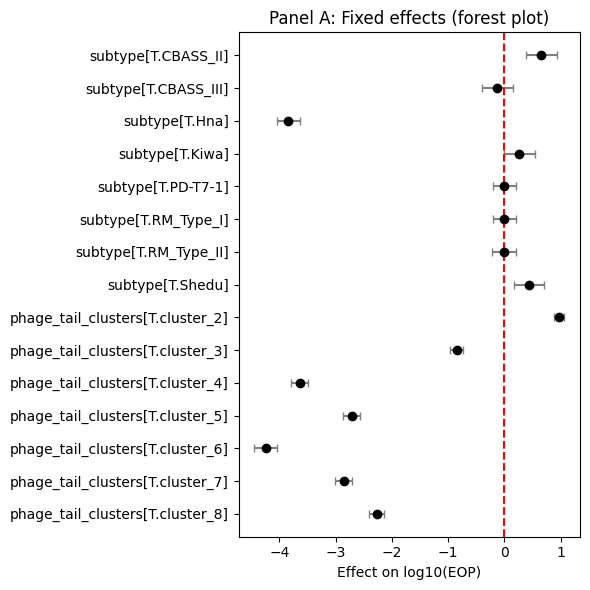

In [55]:
# Extract coefficients and 95% CI
coefs = result.fe_params
ci = result.conf_int()
ci_lower = ci[0]
ci_upper = ci[1]

# Optional: select only effects of interest
effects_of_interest = [c for c in coefs.index if "subtype" in c or "phage_tail_clusters" in c]
coefs_sel = coefs[effects_of_interest]
ci_lower_sel = ci_lower[effects_of_interest]
ci_upper_sel = ci_upper[effects_of_interest]

# Plot
plt.figure(figsize=(6, len(coefs_sel)*0.4))
plt.errorbar(coefs_sel, range(len(coefs_sel)),
             xerr=[coefs_sel - ci_lower_sel, ci_upper_sel - coefs_sel],
             fmt='o', color='black', ecolor='gray', capsize=3)
plt.yticks(range(len(coefs_sel)), coefs_sel.index)
plt.axvline(0, color='red', linestyle='--')
plt.gca().invert_yaxis()
plt.xlabel("Effect on log10(EOP)")
plt.title("Panel A: Fixed effects (forest plot)")
plt.tight_layout()
plt.show()


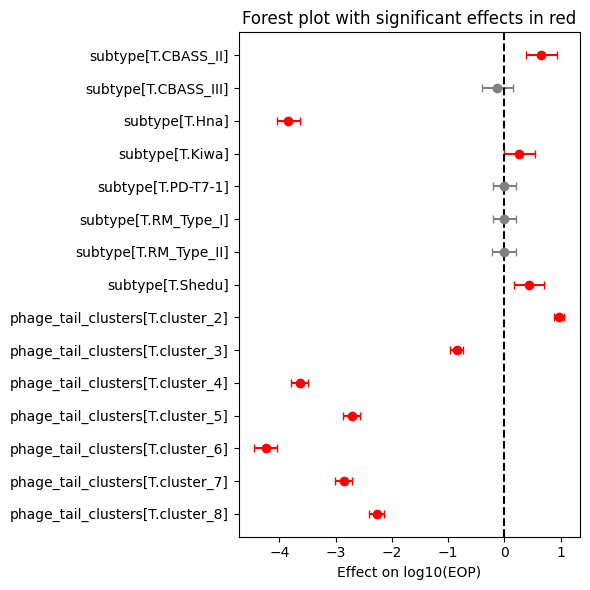

In [60]:
import matplotlib.pyplot as plt

# Extract coefficients and CI
coefs = result.fe_params
ci = result.conf_int()
ci_lower = ci[0]
ci_upper = ci[1]

# Boolean array: True if significant
significant = ~((ci_lower < 0) & (ci_upper > 0))

effects_of_interest = [c for c in coefs.index if "subtype" in c or "phage_tail_clusters" in c]
coefs_sel = coefs[effects_of_interest]
ci_lower_sel = ci_lower[effects_of_interest]
ci_upper_sel = ci_upper[effects_of_interest]
significant_sel = significant[effects_of_interest]

plt.figure(figsize=(6, len(coefs_sel)*0.4))

# Iterate through each effect and plot it individually with its corresponding color
for i, (effect_name, coef) in enumerate(coefs_sel.items()):
    is_significant = significant_sel[effect_name]
    color = "red" if is_significant else "gray"
    plt.errorbar(coef, i,
                 xerr=[[coef - ci_lower_sel[effect_name]], [ci_upper_sel[effect_name] - coef]],
                 fmt='o', ecolor=color, color=color, capsize=3)

plt.axvline(0, color='black', linestyle='--')
plt.yticks(range(len(coefs_sel)), coefs_sel.index)
plt.gca().invert_yaxis()
plt.xlabel("Effect on log10(EOP)")
plt.title("Forest plot with significant effects in red")
plt.tight_layout()
plt.show()

# Condition 2

Testing if the phage taxa have any effect on EOP, and what variables explain that

In [61]:
import statsmodels.api as sm
from statsmodels.formula.api import mixedlm
import pandas as pd
import numpy as np

# Make sure categorical variables are correctly typed
categorical_cols = [
    "subtype",            # Defence system
    "AMR_class_x",        # AMR gene class
    "AMR_phenotype",      # AMR phenotype
    "phage_tail_clusters", # Phage genomic cluster
]

for col in categorical_cols:
    df[col] = df[col].astype("category")

# Make sure log_EOP exists
df["log_EOP"] = np.log10(df["EOP_value"])

# Fit the full LMM
model = mixedlm(
    "log_EOP ~ subtype + AMR_class_x + AMR_phenotype + phage_tail_clusters",
    data=df,
    groups=df["phage_taxa"]  # random intercept for each phage taxa
)

result = model.fit()
print(result.summary())


                           Mixed Linear Model Regression Results
Model:                       MixedLM            Dependent Variable:            log_EOP     
No. Observations:            40176              Method:                        REML        
No. Groups:                  2                  Scale:                         13.0731     
Min. group size:             6480               Log-Likelihood:                -108687.4924
Max. group size:             33696              Converged:                     Yes         
Mean group size:             20088.0                                                       
-------------------------------------------------------------------------------------------
                                               Coef.  Std.Err.    z    P>|z|  [0.025 0.975]
-------------------------------------------------------------------------------------------
Intercept                                       2.024    3.617   0.559 0.576  -5.066  9.113
subtype[T.CBASS

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


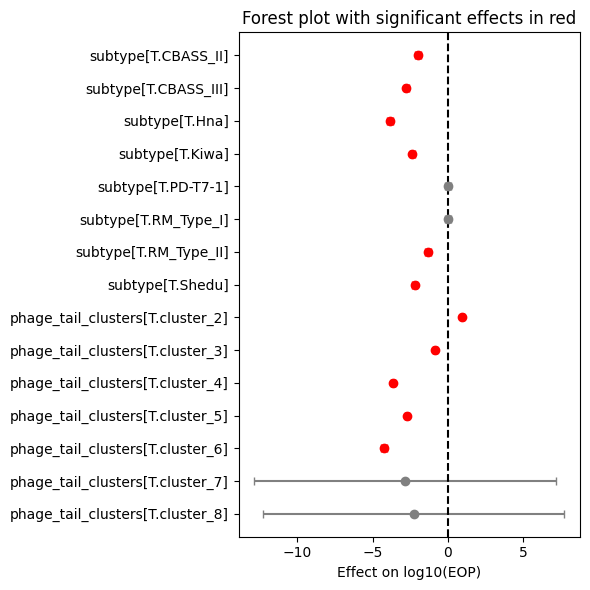

In [62]:
import matplotlib.pyplot as plt

# Extract coefficients and CI
coefs = result.fe_params
ci = result.conf_int()
ci_lower = ci[0]
ci_upper = ci[1]

# Boolean array: True if significant
significant = ~((ci_lower < 0) & (ci_upper > 0))

effects_of_interest = [c for c in coefs.index if "subtype" in c or "phage_tail_clusters" in c]
coefs_sel = coefs[effects_of_interest]
ci_lower_sel = ci_lower[effects_of_interest]
ci_upper_sel = ci_upper[effects_of_interest]
significant_sel = significant[effects_of_interest]

plt.figure(figsize=(6, len(coefs_sel)*0.4))

# Iterate through each effect and plot it individually with its corresponding color
for i, (effect_name, coef) in enumerate(coefs_sel.items()):
    is_significant = significant_sel[effect_name]
    color = "red" if is_significant else "gray"
    plt.errorbar(coef, i,
                 xerr=[[coef - ci_lower_sel[effect_name]], [ci_upper_sel[effect_name] - coef]],
                 fmt='o', ecolor=color, color=color, capsize=3)

plt.axvline(0, color='black', linestyle='--')
plt.yticks(range(len(coefs_sel)), coefs_sel.index)
plt.gca().invert_yaxis()
plt.xlabel("Effect on log10(EOP)")
plt.title("Forest plot with significant effects in red")
plt.tight_layout()
plt.show()

# Condition 3

Tested if both phage and bacterial taxa have any effect

In [63]:
import statsmodels.api as sm
from statsmodels.formula.api import mixedlm

# Ensure categorical types
df["phage_taxa"] = df["phage_taxa"].astype("category")
df["host_species"] = df["host_species"].astype("category")

# Fixed effects example (adjust as needed)
fixed_effects = "subtype + AMR_class_x + AMR_phenotype + phage_tail_clusters"

# Variance components for multiple random effects
vc = {
    "phage_taxa": "0 + C(phage_taxa)",
    "host_species": "0 + C(host_species)"
}

# Fit the mixed model
model = mixedlm(
    f"log_EOP ~ {fixed_effects}",
    data=df,
    groups=df["bacteria"],  # still need a main grouping for random intercept
    vc_formula=vc
)

result = model.fit()
print(result.summary())


                          Mixed Linear Model Regression Results
Model:                        MixedLM           Dependent Variable:           log_EOP     
No. Observations:             40176             Method:                       REML        
No. Groups:                   6                 Scale:                        12.0389     
Min. group size:              2232              Log-Likelihood:               -107062.0154
Max. group size:              8928              Converged:                    Yes         
Mean group size:              6696.0                                                      
------------------------------------------------------------------------------------------
                                               Coef.  Std.Err.    z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------
Intercept                                      -0.056    0.976  -0.057 0.954 -1.970  1.858
subtype[T.CBASS_II]       

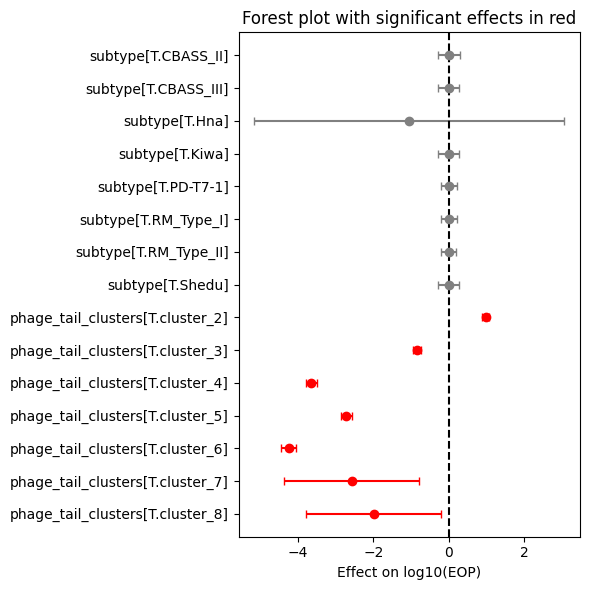

In [64]:
import matplotlib.pyplot as plt

# Extract coefficients and CI
coefs = result.fe_params
ci = result.conf_int()
ci_lower = ci[0]
ci_upper = ci[1]

# Boolean array: True if significant
significant = ~((ci_lower < 0) & (ci_upper > 0))

effects_of_interest = [c for c in coefs.index if "subtype" in c or "phage_tail_clusters" in c]
coefs_sel = coefs[effects_of_interest]
ci_lower_sel = ci_lower[effects_of_interest]
ci_upper_sel = ci_upper[effects_of_interest]
significant_sel = significant[effects_of_interest]

plt.figure(figsize=(6, len(coefs_sel)*0.4))

# Iterate through each effect and plot it individually with its corresponding color
for i, (effect_name, coef) in enumerate(coefs_sel.items()):
    is_significant = significant_sel[effect_name]
    color = "red" if is_significant else "gray"
    plt.errorbar(coef, i,
                 xerr=[[coef - ci_lower_sel[effect_name]], [ci_upper_sel[effect_name] - coef]],
                 fmt='o', ecolor=color, color=color, capsize=3)

plt.axvline(0, color='black', linestyle='--')
plt.yticks(range(len(coefs_sel)), coefs_sel.index)
plt.gca().invert_yaxis()
plt.xlabel("Effect on log10(EOP)")
plt.title("Forest plot with significant effects in red")
plt.tight_layout()
plt.show()

# Condition 4

Since defense systems and phage tail clusters consistently come up as significant in the model. I am testing to see if their interaction matters (as a fixed effect together)

In [65]:
import statsmodels.api as sm
from statsmodels.formula.api import mixedlm

# Ensure categorical types
df["phage_taxa"] = df["phage_taxa"].astype("category")
df["host_species"] = df["host_species"].astype("category")

# Fixed effects example (adjust as needed)
fixed_effects = "subtype * phage_tail_clusters"

# Variance components for multiple random effects
vc = {
    "phage_taxa": "0 + C(phage_taxa)",
    "host_species": "0 + C(host_species)"
}

# Fit the mixed model
model = mixedlm(
    f"log_EOP ~ {fixed_effects}",
    data=df,
    groups=df["bacteria"],  # still need a main grouping for random intercept
    vc_formula=vc
)

result = model.fit()
print(result.summary())


                              Mixed Linear Model Regression Results
Model:                          MixedLM              Dependent Variable:              log_EOP     
No. Observations:               40176                Method:                          REML        
No. Groups:                     6                    Scale:                           11.7324     
Min. group size:                2232                 Log-Likelihood:                  -106518.8865
Max. group size:                8928                 Converged:                       Yes         
Mean group size:                6696.0                                                            
--------------------------------------------------------------------------------------------------
                                                       Coef.  Std.Err.    z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------------------------
Intercept                                

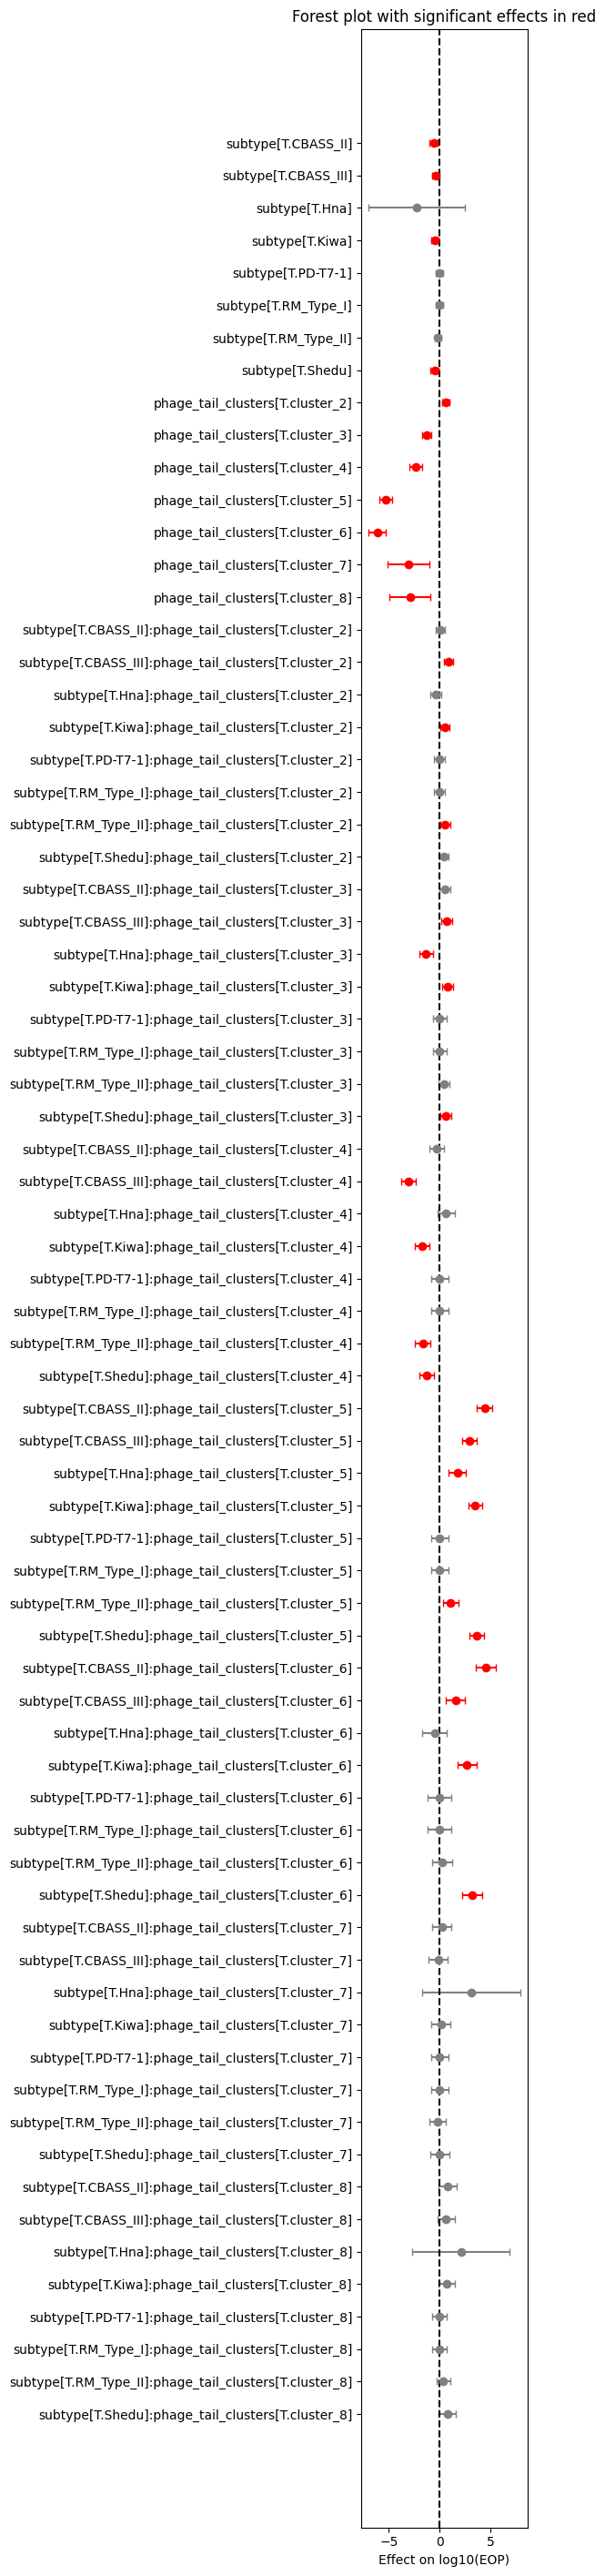

In [66]:
import matplotlib.pyplot as plt

# Extract coefficients and CI
coefs = result.fe_params
ci = result.conf_int()
ci_lower = ci[0]
ci_upper = ci[1]

# Boolean array: True if significant
significant = ~((ci_lower < 0) & (ci_upper > 0))

effects_of_interest = [c for c in coefs.index if "subtype" in c or "phage_tail_clusters" in c]
coefs_sel = coefs[effects_of_interest]
ci_lower_sel = ci_lower[effects_of_interest]
ci_upper_sel = ci_upper[effects_of_interest]
significant_sel = significant[effects_of_interest]

plt.figure(figsize=(6, len(coefs_sel)*0.4))

# Iterate through each effect and plot it individually with its corresponding color
for i, (effect_name, coef) in enumerate(coefs_sel.items()):
    is_significant = significant_sel[effect_name]
    color = "red" if is_significant else "gray"
    plt.errorbar(coef, i,
                 xerr=[[coef - ci_lower_sel[effect_name]], [ci_upper_sel[effect_name] - coef]],
                 fmt='o', ecolor=color, color=color, capsize=3)

plt.axvline(0, color='black', linestyle='--')
plt.yticks(range(len(coefs_sel)), coefs_sel.index)
plt.gca().invert_yaxis()
plt.xlabel("Effect on log10(EOP)")
plt.title("Forest plot with significant effects in red")
plt.tight_layout()
plt.show()

#Not testing interaction across all the variables

In [8]:
import statsmodels.api as sm
from statsmodels.formula.api import mixedlm

# Ensure categorical types
df["phage_taxa"] = df["phage_taxa"].astype("category")
df["host_species"] = df["host_species"].astype("category")

# Fixed effects example (adjust as needed)
fixed_effects = "subtype * phage_tail_clusters * AMR_class_x"

# Variance components for multiple random effects
vc = {
    "phage_taxa": "0 + C(phage_taxa)",
    "host_species": "0 + C(host_species)"
}

# Fit the mixed model
model = mixedlm(
    f"log_EOP ~ {fixed_effects}",
    data=df,
    groups=df["bacteria"],  # still need a main grouping for random intercept
    vc_formula=vc
)

result = model.fit()
print(result.summary())


                                             Mixed Linear Model Regression Results
Model:                                    MixedLM                        Dependent Variable:                        log_EOP     
No. Observations:                         40176                          Method:                                    REML        
No. Groups:                               6                              Scale:                                     9.1718      
Min. group size:                          2232                           Log-Likelihood:                            -101351.6793
Max. group size:                          8928                           Converged:                                 Yes         
Mean group size:                          6696.0                                                                                
--------------------------------------------------------------------------------------------------------------------------------
              